In [31]:
# =========================
# IMPORTACIÓN
# =========================

import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import clear_output
import time

# =========================
# CONSTANTES GLOBALES
# =========================

VALOR_MAXIMO_SENSOR = 255
HORAS_DURACION_SUMINISTRO_LLENO = 36
MUESTRAS_POR_HORA = 2
MUESTRAS_DURACION_SUMINISTRO_LLENO = HORAS_DURACION_SUMINISTRO_LLENO * MUESTRAS_POR_HORA
PENDIENTE_FIJA_VACIADO = VALOR_MAXIMO_SENSOR / MUESTRAS_DURACION_SUMINISTRO_LLENO
LIMITE_ATIPICO_REGRESION = 24
UMBRAL_ESTIMACION = 30


In [32]:
# =========================
# GENERACIÓN DE SIMULACIÓN - FUNCIÓN
# =========================

def generar_array_contenedor():
    N = 48
    max_val = 255

    nivel = random.randint(20, 180)

    datos = [nivel]
    datosConRuido = [nivel]

    num_vaciamientos = random.randint(1, 4)
    posiciones_vaciado = random.sample(range(1, N), num_vaciamientos)

    num_llenados = random.choices(
        [0, 1],
        weights=[50, 50],
        k=1
    )[0]

    posiciones_llenado = (
        random.sample(range(1, N), num_llenados)
        if num_llenados > 0
        else []
    )

    for i in range(1, N):
        actual = datos[-1]

        if i in posiciones_vaciado:
            bajada = random.randint(40, 60)
            actual += bajada

        if i in posiciones_llenado:
            r = random.random()
            if r < 0.5:
                capacidad = 0.90
            elif r < 0.8:
                capacidad = 0.85
            else:
                capacidad = 0.95
            nuevo_nivel = int((1 - capacidad) * max_val)
            if nuevo_nivel < actual:
                actual = nuevo_nivel

        actual = max(0, min(255, actual))
        ruido = random.randint(-10, 10)
        actualConRuido = actual + ruido
        actualConRuido = max(0, min(255, actualConRuido))
        datos.append(actual)
        datosConRuido.append(actualConRuido)

    return (
        np.array(datos, dtype=np.uint8),
        np.array(datosConRuido, dtype=np.uint8),
        posiciones_vaciado,
        posiciones_llenado
    )


In [33]:
# =========================
# FUNCIÓN DE ANÁLISIS
# =========================

def analizar_simulacion(array, arrayConRuido, posiciones_vaciado, posiciones_llenado):
    """
    Analiza la simulación para separar la parte analítica de la visual.
    Calcula regresión, estimación con pendiente fija, límites de llenado y estado final.
    """
    x = np.arange(len(array))

    # 1. Calcular regresión lineal desde el último llenado
    if len(posiciones_llenado) > 0:
        inicio_regresion = posiciones_llenado[-1]
    else:
        inicio_regresion = 0

    x_reg = x[inicio_regresion:]
    y_reg = arrayConRuido[inicio_regresion:].astype(float)

    pendiente = None
    intercepto = None
    y_linea_reg = None
    n_estimado_255 = None
    horas_estimadas = None
    texto_estimacion = 'No hay suficientes datos para regresión'
    estimacion = None
    x_linea_plot = None
    y_linea_plot = None

    if len(x_reg) >= 2:
        pendiente, intercepto = np.polyfit(x_reg, y_reg, 1)
        pendiente = float(pendiente)
        intercepto = float(intercepto)
        y_linea_reg = pendiente * x + intercepto

        if pendiente > 0:
            n_estimado_255 = (VALOR_MAXIMO_SENSOR - intercepto) / pendiente
            horas_estimadas = (n_estimado_255 - (len(arrayConRuido) - 1)) * 0.5
            texto_estimacion = f'N={n_estimado_255:.1f} ({horas_estimadas:.1f} h)'
            estimacion = float(horas_estimadas)
        else:
            texto_estimacion = 'No se estima vaciado: pendiente <= 0'

    # 2. Calcular línea extendida para el gráfico de regresión
    if y_linea_reg is not None:
        if n_estimado_255 is not None and np.isfinite(n_estimado_255):
            x_linea_plot = np.linspace(inicio_regresion, max(x[-1], n_estimado_255), 300)
        else:
            x_linea_plot = np.linspace(inicio_regresion, x[-1], 300)
        y_linea_plot = pendiente * x_linea_plot + intercepto

    # 3. Calcular línea de pendiente fija basada únicamente en el último dato registrado
    x_ultimo = len(arrayConRuido) - 1
    y_ultimo = float(arrayConRuido[-1])
    pendiente_fija = PENDIENTE_FIJA_VACIADO
    intercepto_fijo = y_ultimo - pendiente_fija * x_ultimo

    n_estimado_fijo = (VALOR_MAXIMO_SENSOR - intercepto_fijo) / pendiente_fija
    horas_estimadas_fijas = (n_estimado_fijo - x_ultimo) * 0.5
    texto_estimacion_fija = f'N={n_estimado_fijo:.1f} ({horas_estimadas_fijas:.1f} h)'

    # Línea de pendiente fija para el gráfico principal:
    # siempre se calcula para las muestras existentes, es decir, de 0 a 47.
    # El cruce futuro con 255 se conserva para el focus, pero no expande el main.
    x_linea_fija = np.arange(0, len(arrayConRuido))
    y_linea_fija = pendiente_fija * x_linea_fija + intercepto_fijo

    # 4. Calcular franjas de llenado
    franjas_porc = [0.8, 0.5, 0.2]
    limites = [int(round((1 - p) * VALOR_MAXIMO_SENSOR)) for p in franjas_porc]
    limite_80, limite_50, limite_20 = limites
    franjas_estado = [
        (0, limite_80, '#B8F2E6', '00 lleno o casi lleno'),
        (limite_80 + 1, limite_50, '#AED9E0', '01 capacidad a la mitad'),
        (limite_50 + 1, limite_20, '#FAF3B0', '10 alerta para cargar'),
        (limite_20 + 1, VALOR_MAXIMO_SENSOR, '#F7C6C7', '11 vacío'),
    ]

    # 5. Clasificar último valor
    ultimo_valor = int(arrayConRuido[-1])
    llenado = None
    for y_min, y_max, color, etiqueta in franjas_estado:
        if y_min <= ultimo_valor <= y_max:
            llenado = etiqueta
            break

    return (
        x,
        inicio_regresion,
        pendiente,
        intercepto,
        y_linea_reg,
        n_estimado_255,
        horas_estimadas,
        texto_estimacion,
        x_linea_plot,
        y_linea_plot,
        franjas_estado,
        llenado,
        estimacion,
        pendiente_fija,
        intercepto_fijo,
        x_linea_fija,
        y_linea_fija,
        n_estimado_fijo,
        horas_estimadas_fijas,
        texto_estimacion_fija
    )


In [34]:
# =========================
# FUNCIÓN DE GRÁFICO
# =========================

def generar_grafico(array, arrayConRuido, posiciones_vaciado, posiciones_llenado, analisis):
    """
    Genera la visualización de la simulación utilizando los datos ya analizados.
    No recalcula ninguna parte analítica.
    """
    (
        x,
        inicio_regresion,
        pendiente,
        intercepto,
        y_linea_reg,
        n_estimado_255,
        horas_estimadas,
        texto_estimacion,
        x_linea_plot,
        y_linea_plot,
        franjas_estado,
        llenado,
        estimacion,
        pendiente_fija,
        intercepto_fijo,
        x_linea_fija,
        y_linea_fija,
        n_estimado_fijo,
        horas_estimadas_fijas,
        texto_estimacion_fija
    ) = analisis

    tolerancia_evento = 1.5
    franjas_porc = [0.8, 0.5, 0.2]

    fig = plt.figure(figsize=(10, 7), dpi=80)
    gs = GridSpec(6, 3, figure=fig, width_ratios=[2, 2, 1.8], height_ratios=[1, 1, 1, 1, 1, 1])

    ax_main = fig.add_subplot(gs[:, 0:2])
    gs_focus = gs[0:3, 2].subgridspec(
        2, 1,
        hspace=0.45
    )
    ax_focus_reg = fig.add_subplot(gs_focus[0, 0])
    ax_focus_fijo = fig.add_subplot(gs_focus[1, 0])
    ax_conv1 = fig.add_subplot(gs[3, 2])
    ax_conv2 = fig.add_subplot(gs[4, 2])
    ax_conv3 = fig.add_subplot(gs[5, 2])

    # Main plot
    for y_min, y_max, color, etiqueta in franjas_estado:
        ax_main.axhspan(y_min, y_max, color=color, alpha=0.25, zorder=0)

    ax_main.plot(x, array, linestyle='-', label='Datos sin ruido', zorder=3)
    ax_main.scatter(x, arrayConRuido, label='Datos con ruido', zorder=4)

    color_llenado = '#2CA02C'
    color_vaciamiento = '#D62728'
    color_linea_evento = '#1f77b4'

    for pos in posiciones_vaciado:
        ax_main.axvspan(pos - tolerancia_evento, pos + tolerancia_evento, alpha=0.08, zorder=1)
        ax_main.axvline(pos, linestyle='--', alpha=0.45, zorder=2)
        ax_main.scatter(pos, array[pos], color=color_vaciamiento, marker='v', s=120, zorder=7, label='Vaciamiento' if pos == posiciones_vaciado[0] else None)

    for pos in posiciones_llenado:
        ax_main.axvspan(pos - tolerancia_evento, pos + tolerancia_evento, alpha=0.08, zorder=1)
        ax_main.axvline(pos, linestyle=':', alpha=0.55, zorder=2)
        ax_main.scatter(pos, array[pos], color=color_llenado, marker='^', s=120, zorder=7, label='Llenado' if pos == posiciones_llenado[0] else None)

    if y_linea_reg is not None and x_linea_plot is not None and y_linea_plot is not None:
        ax_main.plot(x_linea_plot, y_linea_plot, linestyle='--', color='#ff7f0e', label='Regresión lineal', zorder=5)
        if n_estimado_255 is not None and np.isfinite(n_estimado_255) and 0 <= n_estimado_255 <= len(array) - 1:
            ax_main.scatter([n_estimado_255], [VALOR_MAXIMO_SENSOR], marker='x', s=100, color='#ff7f0e', label='Colisión regresión', zorder=6)

    # Línea verde de pendiente fija en el gráfico principal
    if x_linea_fija is not None and y_linea_fija is not None:
        ax_main.plot(x_linea_fija, y_linea_fija, linestyle='--', color='green', label='Proyección pendiente fija', zorder=5)
        if n_estimado_fijo is not None and np.isfinite(n_estimado_fijo) and 0 <= n_estimado_fijo <= len(array) - 1:
            ax_main.scatter([n_estimado_fijo], [VALOR_MAXIMO_SENSOR], marker='x', s=100, color='green', label='Colisión pendiente fija', zorder=6)

    ax_main.set_xlabel('Mediciones N (cada 30 min)')
    ax_main.set_ylabel('Valor uint8 invertido visualmente')
    ax_main.set_title('Simulación nivel del contenedor en 24h')
    ax_main.grid()
    ax_main.invert_yaxis()
    ax_main.set_ylim(VALOR_MAXIMO_SENSOR, 0)

    # El gráfico principal siempre debe mostrar únicamente las 48 muestras del día: 0 a 47.
    # Los cruces futuros se visualizan en los gráficos focus, no expanden el main.
    ax_main.set_xlim(0, len(array) - 1)

    # Focus superior: regresión normal
    if y_linea_reg is not None and n_estimado_255 is not None and np.isfinite(n_estimado_255):
        x_focus = np.linspace(n_estimado_255 - 5, n_estimado_255 + 5, 150)
        y_focus = pendiente * x_focus + intercepto
        ax_focus_reg.plot(x_focus, y_focus, linestyle='--', color='#ff7f0e', zorder=3)
        ax_focus_reg.axhline(VALOR_MAXIMO_SENSOR, linestyle='-', alpha=0.7, zorder=2)
        ax_focus_reg.scatter([n_estimado_255], [VALOR_MAXIMO_SENSOR], marker='x', s=100, color='#ff7f0e', zorder=4)
        ax_focus_reg.text(0.05, 0.2, texto_estimacion, transform=ax_focus_reg.transAxes, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.85))
        ax_focus_reg.set_xlim(n_estimado_255 - 5, n_estimado_255 + 5)
        ax_focus_reg.set_ylim(VALOR_MAXIMO_SENSOR + 10, VALOR_MAXIMO_SENSOR - 10)
    else:
        ax_focus_reg.text(0.5, 0.5, 'No hay regresión válida para mostrar focus', ha='center', va='center', transform=ax_focus_reg.transAxes)

    ax_focus_reg.set_title('Focus: Regresión')
    ax_focus_reg.set_ylabel('Valor')
    ax_focus_reg.set_yticklabels([])
    ax_focus_reg.grid()

    # Focus inferior: pendiente fija
    if x_linea_fija is not None and n_estimado_fijo is not None and np.isfinite(n_estimado_fijo):
        x_focus_fijo = np.linspace(n_estimado_fijo - 5, n_estimado_fijo + 5, 150)
        y_focus_fijo = pendiente_fija * x_focus_fijo + intercepto_fijo
        ax_focus_fijo.plot(x_focus_fijo, y_focus_fijo, linestyle='--', color='green', zorder=3)
        ax_focus_fijo.axhline(VALOR_MAXIMO_SENSOR, linestyle='-', alpha=0.7, zorder=2)
        ax_focus_fijo.scatter([n_estimado_fijo], [VALOR_MAXIMO_SENSOR], marker='x', s=100, color='green', zorder=4)
        ax_focus_fijo.text(0.05, 0.2, texto_estimacion_fija, transform=ax_focus_fijo.transAxes, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.85))
        ax_focus_fijo.set_xlim(n_estimado_fijo - 5, n_estimado_fijo + 5)
        ax_focus_fijo.set_ylim(VALOR_MAXIMO_SENSOR + 10, VALOR_MAXIMO_SENSOR - 10)
    else:
        ax_focus_fijo.text(0.5, 0.5, 'No hay estimación fija válida para mostrar focus', ha='center', va='center', transform=ax_focus_fijo.transAxes)

    ax_focus_fijo.set_title('Focus: Pendiente fija')
    ax_focus_fijo.set_ylabel('Valor')
    ax_focus_fijo.set_yticklabels([])
    ax_focus_fijo.grid()

    # Convención 1
    ax_conv1.axis('off')
    handles_conv1 = [
        Line2D([0], [0], linestyle='-', label='Datos sin ruido'),
        Line2D([0], [0], linestyle='None', marker='o', label='Datos con ruido'),
        Line2D([0], [0], linestyle='--', color='#ff7f0e', label='Regresión lineal'),
        Line2D([0], [0], linestyle='--', color='green', label='Proyección pendiente fija'),
        Line2D([0], [0], linestyle='None', marker='x', markersize=10, label='Colisión con 255'),
    ]
    ax_conv1.legend(handles=handles_conv1, loc='center', frameon=True, title='Medidas del ultrasónico')

    # Convención 2
    ax_conv2.axis('off')
    handles_conv2 = [
        Patch(facecolor=color_linea_evento, alpha=0.15, label=f'Franja evento ±{tolerancia_evento} N'),
        Line2D([0], [0], color=color_linea_evento, linestyle='--', marker='v', markerfacecolor=color_vaciamiento, markeredgecolor=color_vaciamiento, markersize=8, label='Evento vaciamiento'),
        Line2D([0], [0], color=color_linea_evento, linestyle=':', marker='^', markerfacecolor=color_llenado, markeredgecolor=color_llenado, markersize=8, label='Evento llenado'),
    ]
    ax_conv2.legend(handles=handles_conv2, loc='center', frameon=True, title='Eventos de cambio')

    # Convención 3
    ax_conv3.axis('off')
    porc_lleno = [1.0] + franjas_porc + [0.0]
    handles_conv3 = [
        Patch(facecolor=color, edgecolor=color, alpha=0.35, label=f'{etiqueta}: {porc_lleno[i]*100:.0f}% a {porc_lleno[i+1]*100:.0f}%')
        for i, (y_min, y_max, color, etiqueta) in enumerate(franjas_estado)
    ]
    ax_conv3.legend(handles=handles_conv3, loc='center', frameon=True, title='Franjas de llenado')

    plt.tight_layout()
    plt.show()


In [35]:
# =========================
# FUNCIÓN AUXILIAR: VALIDAR ESTIMACIÓN
# =========================

def estimacion_requiere_correccion(estimacion, umbral=30):
    """
    Retorna True si la estimación es None, no es finita o supera el umbral.
    """
    if estimacion is None:
        return True
    if not np.isfinite(estimacion):
        return True
    if estimacion > umbral:
        return True
    return False


In [36]:
# =========================
# FUNCIÓN AUXILIAR: CORREGIR ESTIMACIÓN
# =========================

def corregir_estimacion(
    estimacion_regresion=None,
    estimacion_pendiente_fija=None,
    umbral=UMBRAL_ESTIMACION,
    limite_atipico=LIMITE_ATIPICO_REGRESION,
    forzar_correccion=False
):
    """
    Centraliza toda corrección de estimación.

    Puede recibir dos estimaciones:
    - estimacion_regresion: estimación calculada por regresión lineal.
    - estimacion_pendiente_fija: estimación calculada con pendiente fija.

    Reglas:
    - Si la regresión es válida y no supera limite_atipico, se conserva.
    - Si la regresión es None, no finita, supera el umbral o supera limite_atipico,
      se obliga a corregir.
    - Si forzar_correccion=True, siempre pregunta aunque la estimación sea válida.

    Opciones del usuario:
    - J: usa la estimación de pendiente fija.
    - N: usa el umbral.
    - float: usa el valor numérico ingresado manualmente.
    """

    estimacion_invalida = (
        estimacion_regresion is None
        or not np.isfinite(estimacion_regresion)
        or estimacion_regresion > umbral
    )

    estimacion_atipica = (
        estimacion_regresion is not None
        and np.isfinite(estimacion_regresion)
        and estimacion_regresion > limite_atipico
    )

    if not forzar_correccion and not estimacion_invalida and not estimacion_atipica:
        return float(estimacion_regresion)

    if estimacion_atipica:
        print('La regresión tiene valores atipicamente altos, corrija')
    elif estimacion_invalida:
        print('La estimación no es válida o supera el umbral permitido, corrija')
    else:
        print('Corrija la estimación')

    while True:
        entrada = input(
            'J = Estimación de pendiente fija\n'
            'N = Umbral\n'
            'O ingrese manualmente la estimación corregida en horas: '
        ).strip().upper()

        if entrada == 'J':
            if estimacion_pendiente_fija is not None and np.isfinite(estimacion_pendiente_fija):
                return float(estimacion_pendiente_fija)
            print('La estimación de pendiente fija no es válida. Ingrese otro valor.')
            continue

        if entrada == 'N':
            return float(umbral)

        try:
            return float(entrada.replace(',', '.'))
        except ValueError:
            print('Debe ingresar J, N o un número válido.')


In [37]:
# =========================
# FUNCIÓN AUXILIAR: CORREGIR LLENADO
# =========================

def corregir_llenado():
    """
    Permite al usuario seleccionar manualmente un estado de llenado válido.
    """
    opciones_validas = {
        "00": "00 lleno o casi lleno",
        "01": "01 capacidad a la mitad",
        "10": "10 alerta para cargar",
        "11": "11 vacío"
    }
    while True:
        print("Opciones de llenado:")
        print("00 = lleno o casi lleno")
        print("01 = capacidad a la mitad")
        print("10 = alerta para cargar")
        print("11 = vacío")
        opcion = input("Ingrese el llenado corregido: ").strip()
        if opcion in opciones_validas:
            return opciones_validas[opcion]
        else:
            print("Opción no válida. Intente nuevamente.")


In [38]:
# =========================
# FUNCIÓN PARA EXPORTAR RESULTADOS A TXT
# =========================

def exportar_resultados_txt(datos_acumulados, nombre_archivo="resultado_iteraciones.txt"):
    """
    Exporta las iteraciones acumuladas a un archivo .txt en formato legible.
    Cada iteración contiene el array con ruido, el estado de llenado y la estimación.
    """
    with open(nombre_archivo, "w", encoding="utf-8") as f:
        for idx, fila in enumerate(datos_acumulados):
            array_con_ruido, llenado, estimacion = fila
            f.write("[")
            f.write(f"{llenado[0:2]}")  # Solo los dos dígitos del estado de llenado
            f.write(",")
            f.write(f"{estimacion}")
            f.write(",")
            f.write(f"{array_con_ruido}]\n")


In [39]:
# =========================
# SISTEMA INTERACTIVO DE ITERACIONES
# =========================

def sistema_iterativo():
    """
    Función principal para realizar iteraciones interactivas sobre la simulación.
    Permite aprobar, corregir o skipear iteraciones y exportar los resultados al finalizar.
    """
    global datos_acumulados

    # Inicializar acumulador si no existe
    try:
        datos_acumulados
    except NameError:
        datos_acumulados = []

    iteraciones = int(input('¿Cuántas iteraciones quieres realizar?: '))
    umbral = UMBRAL_ESTIMACION

    i = len(datos_acumulados)
    while i < iteraciones:
        clear_output(wait=True)
        i = len(datos_acumulados)
        print(f'Iteración {i + 1} de {iteraciones}')
        print(f'Ya acumuladas: {len(datos_acumulados)}')

        array, arrayConRuido, posiciones_vaciado, posiciones_llenado = generar_array_contenedor()
        analisis = analizar_simulacion(array, arrayConRuido, posiciones_vaciado, posiciones_llenado)
        generar_grafico(array, arrayConRuido, posiciones_vaciado, posiciones_llenado, analisis)

        (
            x,
            inicio_regresion,
            pendiente,
            intercepto,
            y_linea_reg,
            n_estimado_255,
            horas_estimadas,
            texto_estimacion,
            x_linea_plot,
            y_linea_plot,
            franjas_estado,
            llenado,
            estimacion,
            pendiente_fija,
            intercepto_fijo,
            x_linea_fija,
            y_linea_fija,
            n_estimado_fijo,
            horas_estimadas_fijas,
            texto_estimacion_fija
        ) = analisis

        print('Último valor array con ruido:', int(arrayConRuido[-1]))
        print('Llenado detectado:', llenado)
        print('Estimación por regresión:', estimacion)
        print('Estimación pendiente fija:', horas_estimadas_fijas)

        # =========================
        # CONTADOR DE NIVELES DE LLENADO
        # =========================

        conteo_llenado = {
            '00 lleno o casi lleno': 0,
            '01 capacidad a la mitad': 0,
            '10 alerta para cargar': 0,
            '11 vacío': 0,
            'None': 0
        }

        for fila in datos_acumulados:
            estado = fila[1]

            if estado is None:
                conteo_llenado['None'] += 1
            elif estado in conteo_llenado:
                conteo_llenado[estado] += 1

        print('\nNiveles de llenado acumulados:')
        print(f"00 lleno o casi lleno     : {conteo_llenado['00 lleno o casi lleno']}")
        print(f"01 capacidad a la mitad   : {conteo_llenado['01 capacidad a la mitad']}")
        print(f"10 alerta para cargar     : {conteo_llenado['10 alerta para cargar']}")
        print(f"11 vacío                  : {conteo_llenado['11 vacío']}")
        print(f"Skipeados / sin clasificar: {conteo_llenado['None']}")

        print('\nOpciones:\nJ = APROBAR\nK = CORREGIR LLENADO\nL = CORREGIR ESTIMACIÓN\nÑ = CORREGIR AMBAS\nN = SKIPEAR\nH = DEVOLVERSE\n')
        opcion = input('Opción: ').strip().upper()

        if opcion == 'H':
            if len(datos_acumulados) == 0:
                print('Ya estás en la primera iteración.')
                time.sleep(1)
            else:
                datos_acumulados.pop()
                i = len(datos_acumulados)
            continue

        if opcion == 'N':
            datos_acumulados.append([arrayConRuido.tolist(), None, None])
            i = len(datos_acumulados)
            continue

        if opcion == 'K':
            llenado = corregir_llenado()
            estimacion = corregir_estimacion(
                estimacion_regresion=estimacion,
                estimacion_pendiente_fija=horas_estimadas_fijas,
                umbral=umbral,
                limite_atipico=LIMITE_ATIPICO_REGRESION,
                forzar_correccion=False
            )

        elif opcion == 'L':
            estimacion = corregir_estimacion(
                estimacion_regresion=estimacion,
                estimacion_pendiente_fija=horas_estimadas_fijas,
                umbral=umbral,
                limite_atipico=LIMITE_ATIPICO_REGRESION,
                forzar_correccion=True
            )

        elif opcion == 'Ñ':
            llenado = corregir_llenado()
            estimacion = corregir_estimacion(
                estimacion_regresion=estimacion,
                estimacion_pendiente_fija=horas_estimadas_fijas,
                umbral=umbral,
                limite_atipico=LIMITE_ATIPICO_REGRESION,
                forzar_correccion=True
            )

        elif opcion == 'J':
            estimacion = corregir_estimacion(
                estimacion_regresion=estimacion,
                estimacion_pendiente_fija=horas_estimadas_fijas,
                umbral=umbral,
                limite_atipico=LIMITE_ATIPICO_REGRESION,
                forzar_correccion=False
            )

        else:
            print('Opción no válida.')
            time.sleep(1)
            continue

        if estimacion is not None:
            estimacion = float(estimacion)

        datos_acumulados.append([arrayConRuido.tolist(), llenado, estimacion])
        i = len(datos_acumulados)

    exportar_resultados_txt(datos_acumulados)
    print('Proceso finalizado. Información exportada en resultado_iteraciones.txt')


Iteración 20 de 20
Ya acumuladas: 19


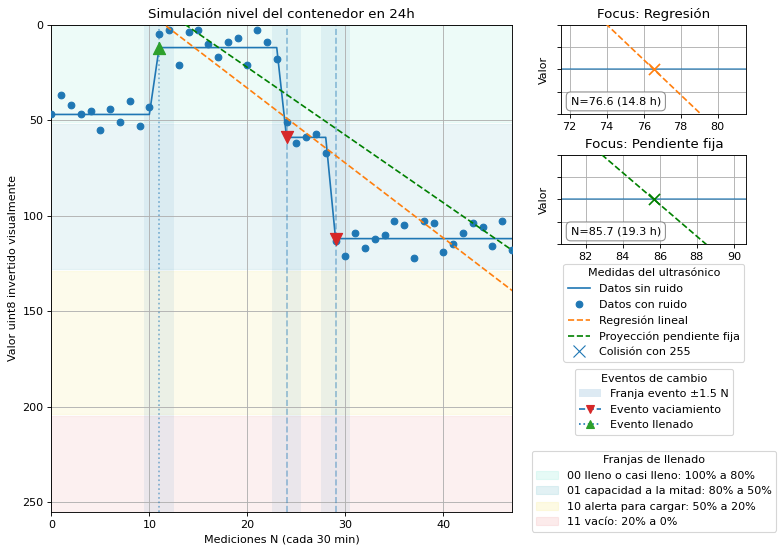

Último valor array con ruido: 118
Llenado detectado: 01 capacidad a la mitad
Estimación por regresión: 14.778718258766624
Estimación pendiente fija: 19.341176470588238

Niveles de llenado acumulados:
00 lleno o casi lleno     : 6
01 capacidad a la mitad   : 5
10 alerta para cargar     : 5
11 vacío                  : 3
Skipeados / sin clasificar: 0

Opciones:
J = APROBAR
K = CORREGIR LLENADO
L = CORREGIR ESTIMACIÓN
Ñ = CORREGIR AMBAS
N = SKIPEAR
H = DEVOLVERSE

Proceso finalizado. Información exportada en resultado_iteraciones.txt


In [40]:
# =========================
# LLAMADA AL SISTEMA INTERACTIVO
# =========================

sistema_iterativo()
